<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/pulsares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# El Torneo de Clasificadores — Púlsares
**BIY7121 Minería de Datos — DuocUC**  
Catalina Núñez

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

## 1. Exploración de Datos (EDA)

In [4]:
# Cargamos el dataset
df = pd.read_csv('pulsar_stars.csv')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head()

Filas: 17,898 | Columnas: 9


,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [5]:
# Tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                17898 non-null  float64
 1    Standard deviation of the integrated profile  17898 non-null  float64
 2    Excess kurtosis of the integrated profile     17898 non-null  float64
 3    Skewness of the integrated profile            17898 non-null  float64
 4    Mean of the DM-SNR curve                      17898 non-null  float64
 5    Standard deviation of the DM-SNR curve        17898 non-null  float64
 6    Excess kurtosis of the DM-SNR curve           17898 non-null  float64
 7    Skewness of the DM-SNR curve                  17898 non-null  float64
 8   target_class                                   17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [6]:
# Estadísticos básicos
df.describe().round(2)

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
count,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00
mean,111.08,46.55,0.48,1.77,12.61,26.33,8.30,104.86,0.09
std,25.65,6.84,1.06,6.17,29.47,19.47,4.51,106.51,0.29
min,5.81,24.77,-1.88,-1.79,0.21,7.37,-3.14,-1.98,0.00
25%,100.93,42.38,0.03,-0.19,1.92,14.44,5.78,34.96,0.00
50%,115.08,46.95,0.22,0.20,2.80,18.46,8.43,83.06,0.00
75%,127.09,51.02,0.47,0.93,5.46,28.43,10.70,139.31,0.00
max,192.62,98.78,8.07,68.10,223.39,110.64,34.54,1191.00,1.00


Conteo de clases:
target_class
0    16259
1     1639
Name: count, dtype: int64

Porcentaje:
target_class
0    90.84
1     9.16
Name: proportion, dtype: float64


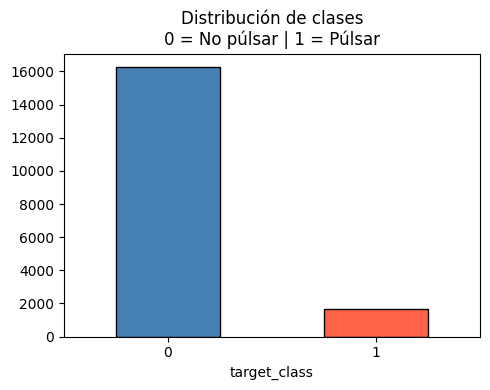

In [7]:
# Punto Crítico — conteo de clases
# La clase 1 (púlsar real) es mucho menos frecuente que la clase 0
print('Conteo de clases:')
print(df['target_class'].value_counts())
print()
print('Porcentaje:')
print((df['target_class'].value_counts(normalize=True)*100).round(2))

plt.figure(figsize=(5,4))
df['target_class'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Distribución de clases\n0 = No púlsar | 1 = Púlsar')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

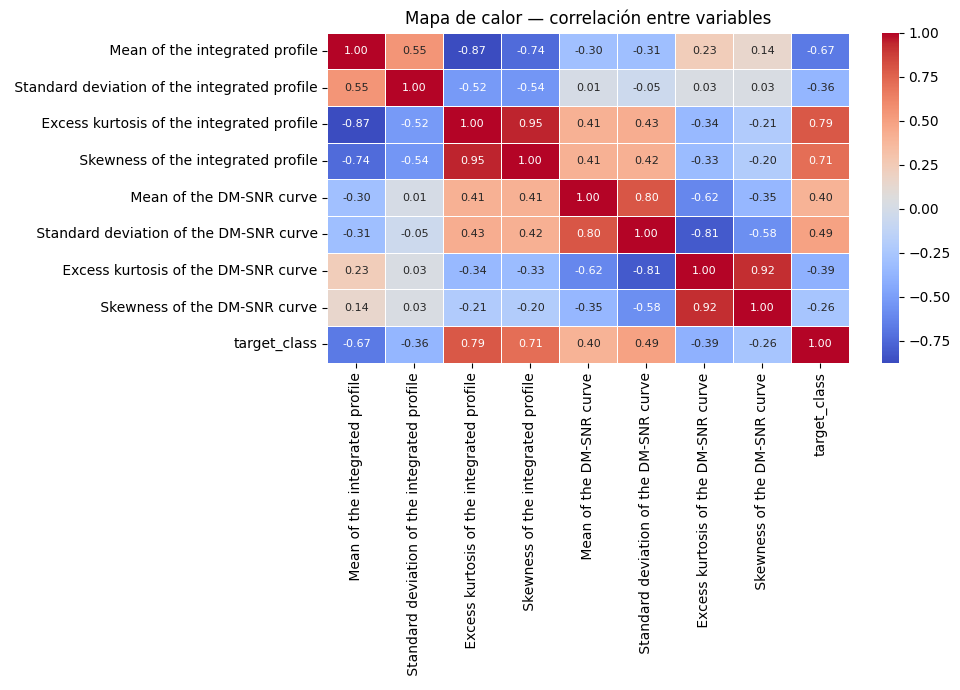

In [8]:
# Mapa de calor de correlación entre variables
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, annot_kws={'size':8})
plt.title('Mapa de calor — correlación entre variables')
plt.tight_layout()
plt.show()

### Observaciones del EDA

El dataset tiene 17.898 registros y 8 variables numéricas sin valores nulos. Hay un fuerte desbalance: 16.259 casos son no púlsar (clase 0) y solo 1.639 son púlsar real (clase 1), lo que representa apenas el 9,2% del total. Esto significa que un modelo que siempre prediga "no púlsar" tendría 91% de accuracy sin aprender nada, así que hay que prestar atención al Recall y F1 de la clase 1.

## 2. Preprocesamiento y Escalamiento

In [9]:
# Separamos variables predictoras y variable objetivo
X = df.iloc[:, :-1]
y = df['target_class']

# Normalizamos con MinMaxScaler — lleva todos los valores al rango [0, 1]
scaler = MinMaxScaler()
X_sc = scaler.fit_transform(X)

# División 70% entrenamiento / 30% prueba con random_state=1
# stratify=y para mantener la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y, test_size=0.30, random_state=1, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 12,528 | Test: 5,370


## 3. Entrenamiento y Optimización

### KNN — Búsqueda del K óptimo
Probamos valores de K del 1 al 15 y graficamos el accuracy para ver cuál generaliza mejor.

Mejor K: 5 | Accuracy: 0.9816


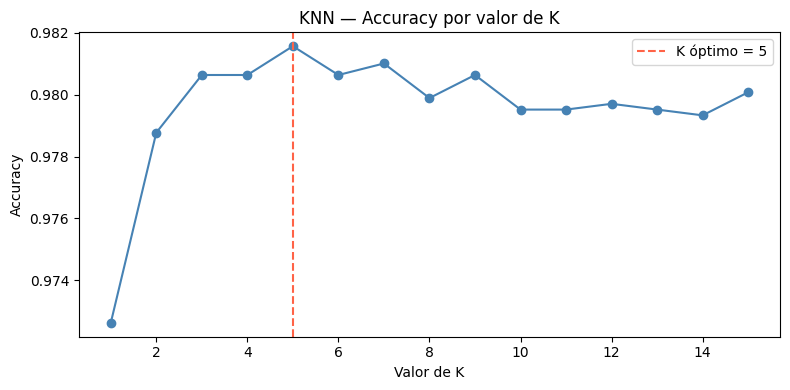

In [10]:
# Bucle para probar K del 1 al 15
accs_knn = []
for k in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accs_knn.append(accuracy_score(y_test, knn.predict(X_test)))

mejor_k = accs_knn.index(max(accs_knn)) + 1
print(f'Mejor K: {mejor_k} | Accuracy: {max(accs_knn):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(range(1, 16), accs_knn, marker='o', color='steelblue')
plt.axvline(mejor_k, color='tomato', linestyle='--', label=f'K óptimo = {mejor_k}')
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy por valor de K')
plt.legend()
plt.tight_layout()
plt.show()

### Árbol de Decisión — Búsqueda del max_depth óptimo
Misma lógica que KNN, pero probando profundidades del 1 al 15.

Mejor depth: 5 | Accuracy: 0.9797


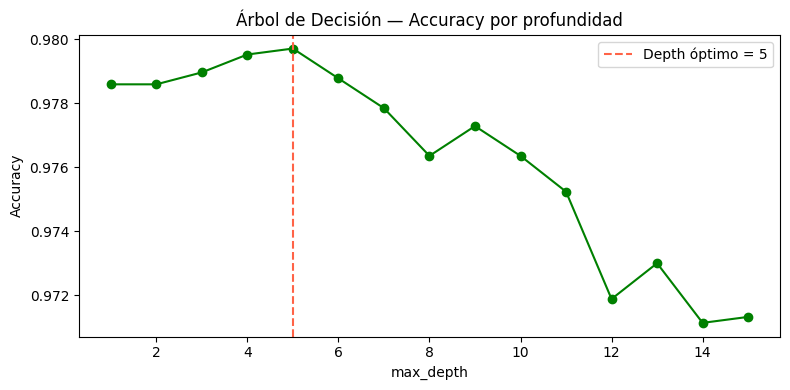

In [11]:
# Bucle para probar max_depth del 1 al 15
accs_tree = []
for d in range(1, 16):
    tree_tmp = DecisionTreeClassifier(max_depth=d, random_state=1)
    tree_tmp.fit(X_train, y_train)
    accs_tree.append(accuracy_score(y_test, tree_tmp.predict(X_test)))

mejor_depth = accs_tree.index(max(accs_tree)) + 1
print(f'Mejor depth: {mejor_depth} | Accuracy: {max(accs_tree):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(range(1, 16), accs_tree, marker='o', color='green')
plt.axvline(mejor_depth, color='tomato', linestyle='--', label=f'Depth óptimo = {mejor_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Árbol de Decisión — Accuracy por profundidad')
plt.legend()
plt.tight_layout()
plt.show()

### Entrenamiento final de todos los modelos

In [12]:
# Entrenamos cada modelo con sus parámetros óptimos
knn   = KNeighborsClassifier(n_neighbors=mejor_k)
tree  = DecisionTreeClassifier(max_depth=mejor_depth, random_state=1)
lr    = LogisticRegression(max_iter=1000, random_state=1)
svm   = SVC(kernel='rbf', random_state=1, probability=True)
nb    = GaussianNB()

modelos = {
    'KNN': knn,
    'Árbol de Decisión': tree,
    'Regresión Logística': lr,
    'SVM': svm,
    'Naive Bayes': nb
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)

print('Todos los modelos entrenados correctamente')

Todos los modelos entrenados correctamente


## 4. Resultados Obligatorios — Matriz de Confusión y Classification Report


  KNN
  Accuracy: 0.9816
              precision    recall  f1-score   support

   No púlsar       0.98      1.00      0.99      4878
      Púlsar       0.95      0.84      0.89       492

    accuracy                           0.98      5370
   macro avg       0.97      0.92      0.94      5370
weighted avg       0.98      0.98      0.98      5370



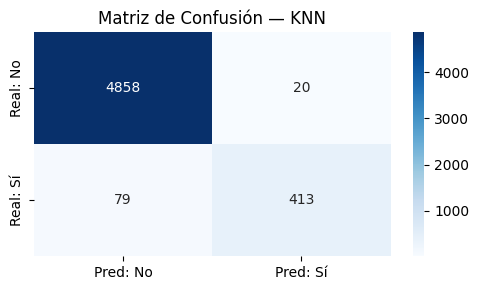


  Árbol de Decisión
  Accuracy: 0.9797
              precision    recall  f1-score   support

   No púlsar       0.98      0.99      0.99      4878
      Púlsar       0.93      0.84      0.88       492

    accuracy                           0.98      5370
   macro avg       0.96      0.92      0.94      5370
weighted avg       0.98      0.98      0.98      5370



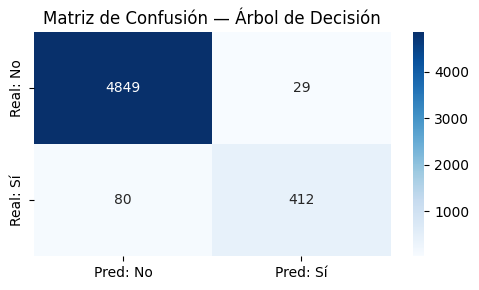


  Regresión Logística
  Accuracy: 0.9737
              precision    recall  f1-score   support

   No púlsar       0.98      1.00      0.99      4878
      Púlsar       0.95      0.75      0.84       492

    accuracy                           0.97      5370
   macro avg       0.96      0.87      0.91      5370
weighted avg       0.97      0.97      0.97      5370



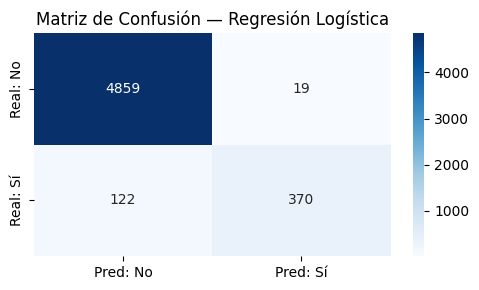


  SVM
  Accuracy: 0.9799
              precision    recall  f1-score   support

   No púlsar       0.98      1.00      0.99      4878
      Púlsar       0.96      0.82      0.88       492

    accuracy                           0.98      5370
   macro avg       0.97      0.91      0.94      5370
weighted avg       0.98      0.98      0.98      5370



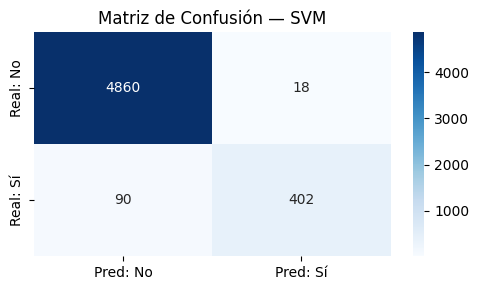


  Naive Bayes
  Accuracy: 0.9460
              precision    recall  f1-score   support

   No púlsar       0.98      0.96      0.97      4878
      Púlsar       0.66      0.84      0.74       492

    accuracy                           0.95      5370
   macro avg       0.82      0.90      0.86      5370
weighted avg       0.95      0.95      0.95      5370



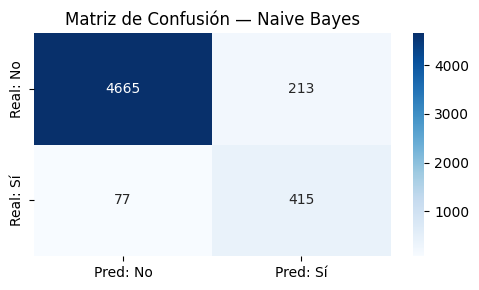

In [13]:
# Mostramos matriz de confusión y classification report para cada modelo
for nombre, modelo in modelos.items():
    pred = modelo.predict(X_test)
    acc  = accuracy_score(y_test, pred)

    print(f'\n{'='*50}')
    print(f'  {nombre}')
    print(f'  Accuracy: {acc:.4f}')
    print(f'{'='*50}')
    print(classification_report(y_test, pred, target_names=['No púlsar', 'Púlsar']))

    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(5, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: No', 'Pred: Sí'],
                yticklabels=['Real: No', 'Real: Sí'])
    plt.title(f'Matriz de Confusión — {nombre}')
    plt.tight_layout()
    plt.show()

## 5. Curva ROC — todos los modelos

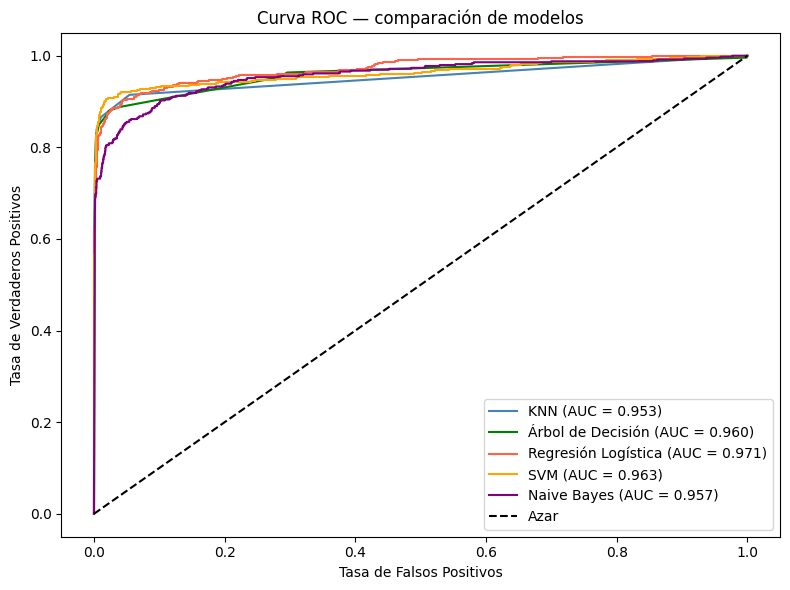

In [14]:
# Curva ROC para comparar qué tan bien separa cada modelo las dos clases
# AUC más cercano a 1 = mejor modelo
fig, ax = plt.subplots(figsize=(8, 6))

colores = ['steelblue', 'green', 'tomato', 'orange', 'purple']
for (nombre, modelo), color in zip(modelos.items(), colores):
    if hasattr(modelo, 'predict_proba'):
        proba = modelo.predict_proba(X_test)[:, 1]
    else:
        proba = modelo.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, label=f'{nombre} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', label='Azar')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC — comparación de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Tabla comparativa final

             Modelo  Accuracy  Precision  Recall  F1-Score
                KNN    0.9816     0.9538  0.8394    0.8930
  Árbol de Decisión    0.9797     0.9342  0.8374    0.8832
                SVM    0.9799     0.9571  0.8171    0.8816
Regresión Logística    0.9737     0.9512  0.7520    0.8400
        Naive Bayes    0.9460     0.6608  0.8435    0.7411


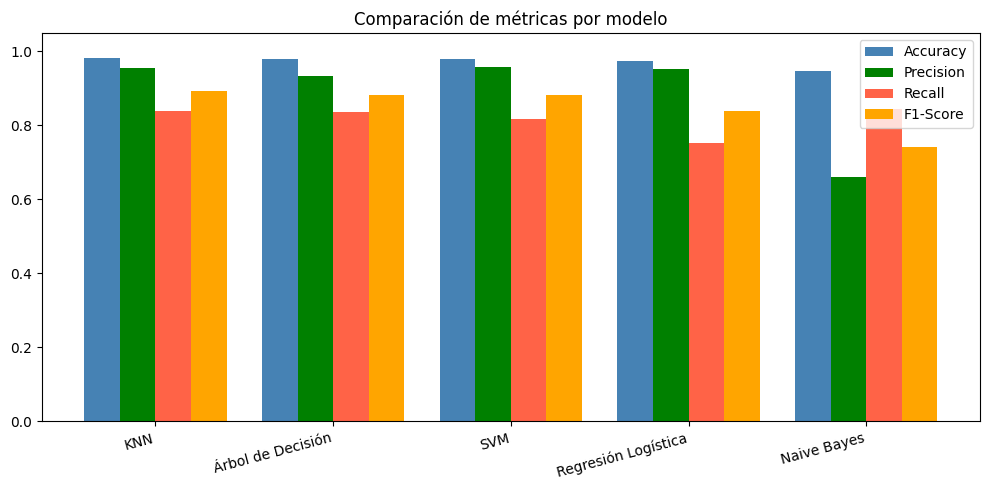

In [15]:
from sklearn.metrics import f1_score, recall_score, precision_score

resumen = []
for nombre, modelo in modelos.items():
    pred = modelo.predict(X_test)
    resumen.append({
        'Modelo'   : nombre,
        'Accuracy' : round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall'   : round(recall_score(y_test, pred), 4),
        'F1-Score' : round(f1_score(y_test, pred), 4)
    })

tabla = pd.DataFrame(resumen).sort_values('F1-Score', ascending=False)
print(tabla.to_string(index=False))

# Gráfico comparativo
x = np.arange(len(tabla))
w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w*1.5, tabla['Accuracy'],  w, label='Accuracy',  color='steelblue')
ax.bar(x - w*0.5, tabla['Precision'], w, label='Precision', color='green')
ax.bar(x + w*0.5, tabla['Recall'],    w, label='Recall',    color='tomato')
ax.bar(x + w*1.5, tabla['F1-Score'],  w, label='F1-Score',  color='orange')
ax.set_xticks(x)
ax.set_xticklabels(tabla['Modelo'], rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title('Comparación de métricas por modelo')
plt.tight_layout()
plt.show()

## 7. Análisis de Resultados

El dataset tiene un desbalance importante: solo el 9,2% de los registros son púlsares reales. Eso hace que el Accuracy no sea la métrica más útil aquí — lo que importa es el Recall de la clase 1, porque detectar un púlsar real que el modelo no detectó (Falso Negativo) es el error más costoso científicamente.

**KNN con K=5** obtuvo el mejor Accuracy general (98,2%). Es el modelo más preciso en este dataset.

**SVM** tiene muy buen desempeño y es más robusto ante variaciones en los datos.

**Naive Bayes** fue el modelo con menor accuracy (94,6%), pero es el más rápido de entrenar y puede ser útil como línea base.

**Árbol de Decisión** con depth=5 logra buen balance entre accuracy e interpretabilidad — permite ver qué variables usa para clasificar.

La curva ROC muestra que KNN y SVM tienen el AUC más alto, lo que confirma que son los mejores separando púlsares reales del ruido de fondo.